In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")

In [ ]:
df = pd.read_csv("EasyVisa.csv")
df.drop("case_id", axis=1, inplace=True)

In [ ]:
# Problem Definition: Print basic info
print("Dataset Shape:", df.shape)
print("Columns:", df.columns)
print("Target Distribution:\n", df['case_status'].value_counts(normalize=True))

Dataset Shape: (25480, 11)
Columns: Index(['continent', 'education_of_employee', 'has_job_experience',
       'requires_job_training', 'no_of_employees', 'yr_of_estab',
       'region_of_employment', 'prevailing_wage', 'unit_of_wage',
       'full_time_position', 'case_status'],
      dtype='object')
Target Distribution:
 case_status
Certified    0.667896
Denied       0.332104
Name: proportion, dtype: float64


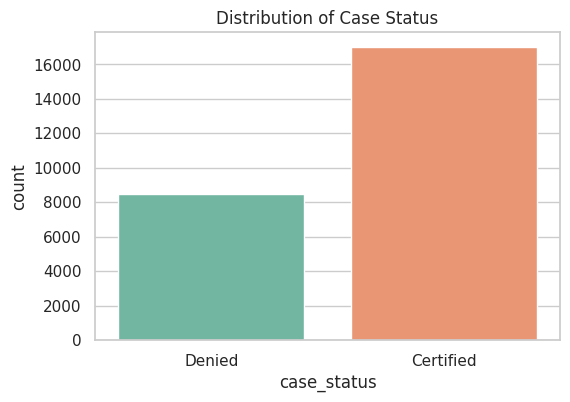

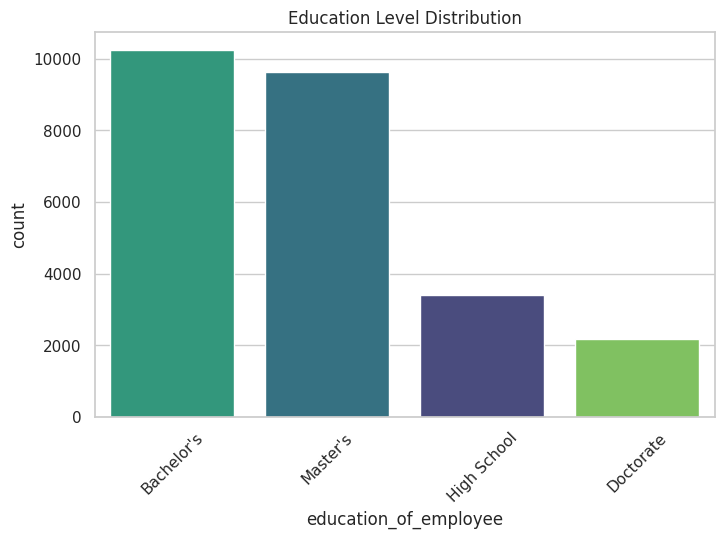

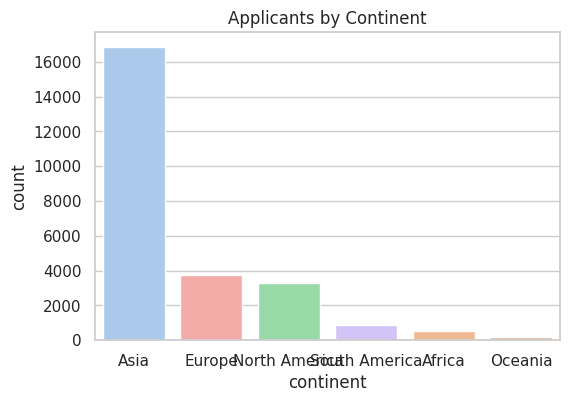

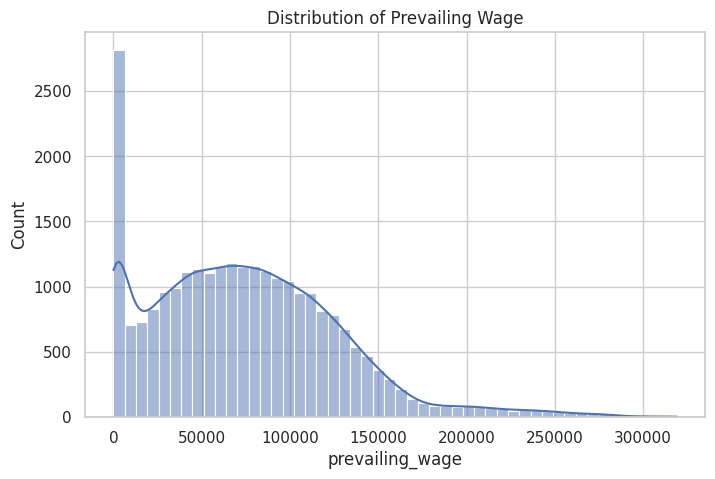

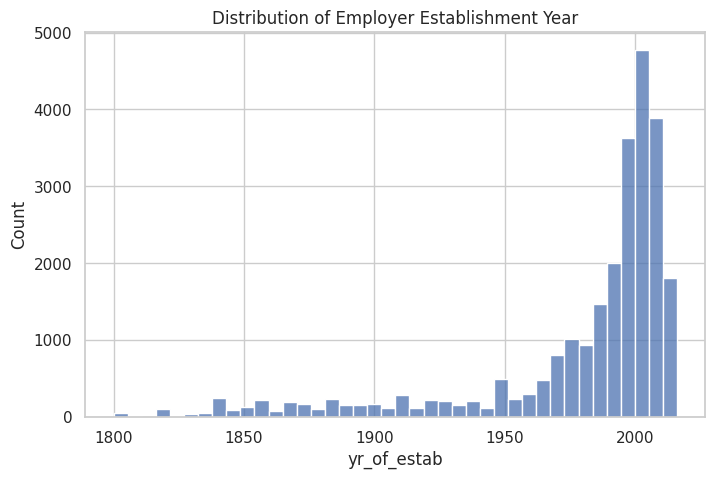

In [ ]:
#Univariate Analysis

# Target variable distribution
plt.figure(figsize=(6,4))
sns.countplot(x="case_status", hue="case_status", data=df, palette="Set2", legend=False)
plt.title("Distribution of Case Status")
plt.show()

# Education of employee
plt.figure(figsize=(8,5))
sns.countplot(x="education_of_employee",     hue="education_of_employee",
data=df, order=df["education_of_employee"].value_counts().index, palette="viridis", legend=False)
plt.title("Education Level Distribution")
plt.xticks(rotation=45)
plt.show()

# Continent
plt.figure(figsize=(6,4))
sns.countplot(x="continent",     hue="continent", data=df, order=df["continent"].value_counts().index, palette="pastel", legend=False)
plt.title("Applicants by Continent")
plt.show()

# Wage Distribution
plt.figure(figsize=(8,5))
sns.histplot(df["prevailing_wage"], bins=50, kde=True)
plt.title("Distribution of Prevailing Wage")
plt.show()

# Year of establishment
plt.figure(figsize=(8,5))
sns.histplot(df["yr_of_estab"], bins=40, kde=False)
plt.title("Distribution of Employer Establishment Year")
plt.show()


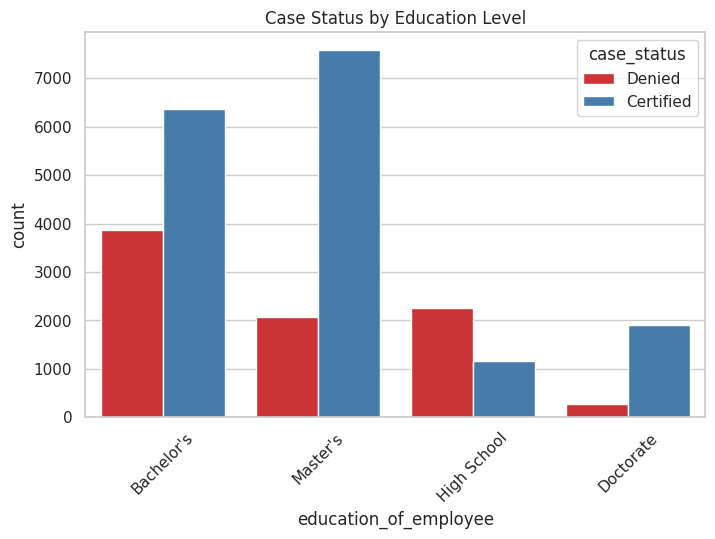

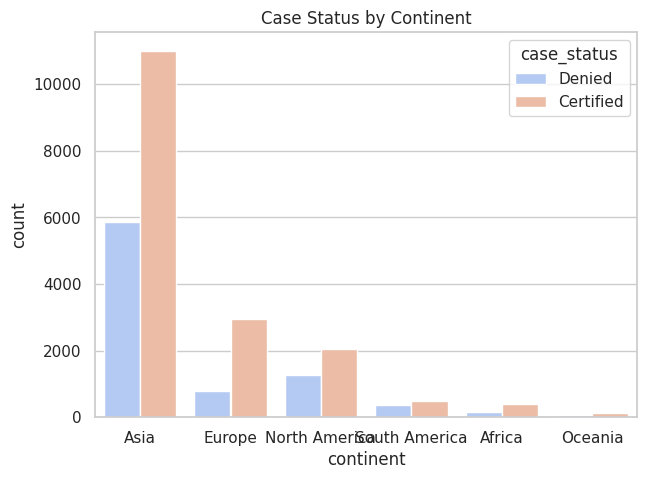

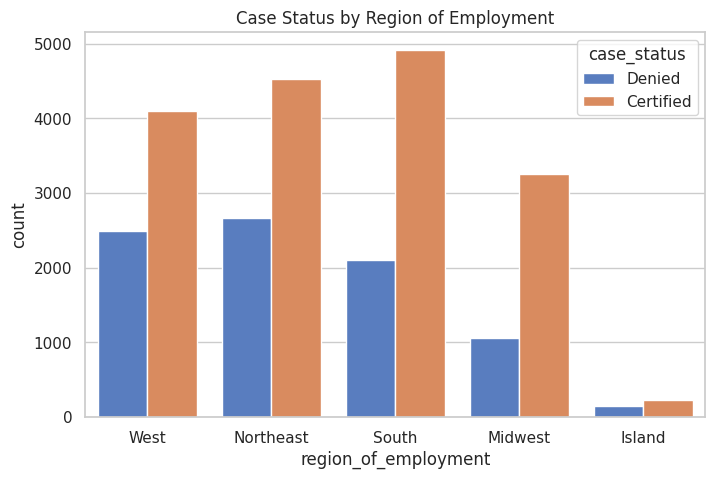

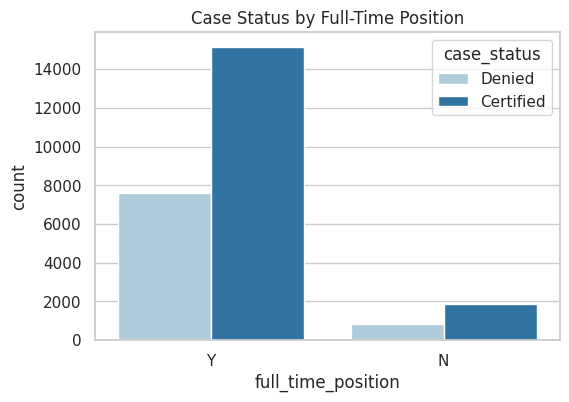

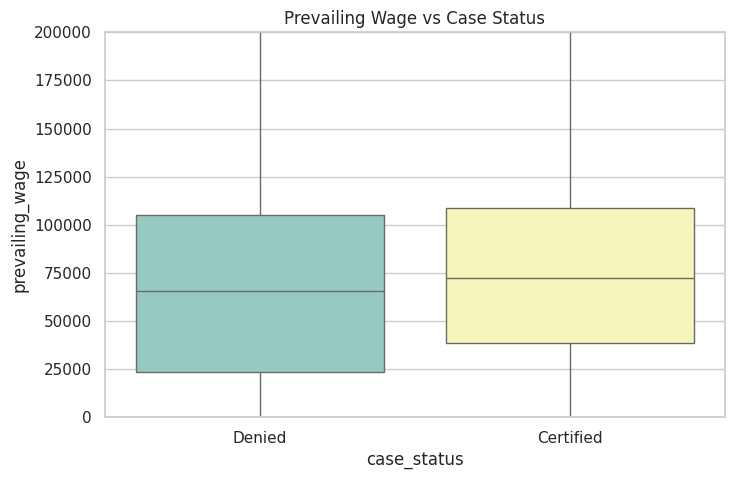

In [ ]:
#Bivariate Analysis

# Case status by Education
plt.figure(figsize=(8,5))
sns.countplot(x="education_of_employee", hue="case_status", data=df,
    order=df["education_of_employee"].value_counts().index,
    palette="Set1")
plt.title("Case Status by Education Level")
plt.xticks(rotation=45)
plt.show()

# Case status by Continent
plt.figure(figsize=(7,5))
sns.countplot(
    x="continent",
    hue="case_status",
    data=df,
    order=df["continent"].value_counts().index,
    palette="coolwarm"
)
plt.title("Case Status by Continent")
plt.show()

# Case status by Region of Employment
plt.figure(figsize=(8,5))
sns.countplot(
    x="region_of_employment",
    hue="case_status",
    data=df,
    palette="muted"
)
plt.title("Case Status by Region of Employment")
plt.show()

# Case status by Full-time Position
plt.figure(figsize=(6,4))
sns.countplot(
    x="full_time_position",
    hue="case_status",
    data=df,
    palette="Paired"
)
plt.title("Case Status by Full-Time Position")
plt.show()

# Prevailing Wage vs Case Status (Boxplot)
plt.figure(figsize=(8,5))
sns.boxplot(
    x="case_status",
    y="prevailing_wage",
    data=df,
    palette="Set3"
)
plt.ylim(0, 200000)   # limit scale for clarity
plt.title("Prevailing Wage vs Case Status")
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure correct data types
categorical_cols = ['continent', 'education_of_employee', 'has_job_experience',
                    'requires_job_training', 'region_of_employment', 'unit_of_wage',
                    'full_time_position', 'case_status']
for col in categorical_cols:
    df[col] = df[col].astype('category')

# Convert target variable to binary
df['case_status'] = df['case_status'].map({'Certified': 1, 'Denied': 0})

# Split data into train, validation, and test sets (60-20-20) with stratification to prevent leakage
train_df, temp_df = train_test_split(df, test_size=0.4, random_state=42, stratify=df['case_status'])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['case_status'])

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)


Train shape: (15288, 11)
Validation shape: (5096, 11)
Test shape: (5096, 11)



Missing Values in Train Set:
 continent                0
education_of_employee    0
has_job_experience       0
requires_job_training    0
no_of_employees          0
yr_of_estab              0
region_of_employment     0
prevailing_wage          0
unit_of_wage             0
full_time_position       0
case_status              0
dtype: int64


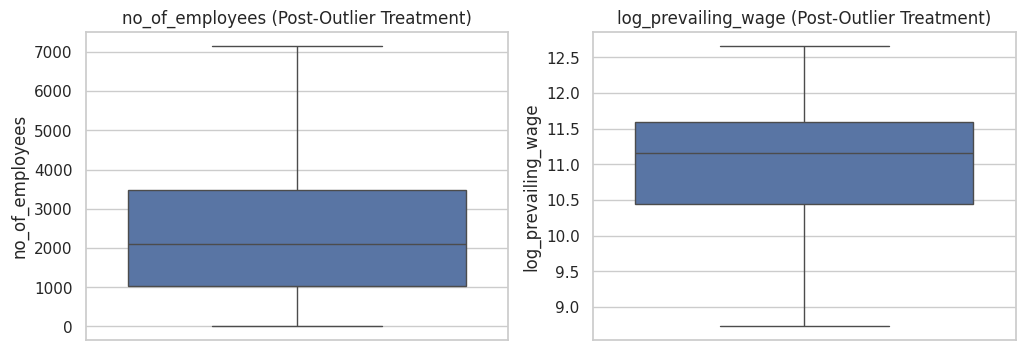

In [ ]:
# 2. Missing Value Treatment
# Check for missing values (none expected)
print("\nMissing Values in Train Set:\n", train_df.isnull().sum())
# No treatment needed as dataset has no missing values

# 3. Outlier Treatment
# Function to cap outliers using IQR method
def cap_outliers(df, column, lower_bound, upper_bound):
    df[column] = df[column].clip(lower=lower_bound, upper=upper_bound)
    return df

# Handle no_of_employees: Convert negative to absolute, then cap outliers
train_df['no_of_employees'] = train_df['no_of_employees'].abs()
Q1 = train_df['no_of_employees'].quantile(0.25)
Q3 = train_df['no_of_employees'].quantile(0.75)
IQR = Q3 - Q1
lower_bound_employees = Q1 - 1.5 * IQR
upper_bound_employees = Q3 + 1.5 * IQR
train_df = cap_outliers(train_df, 'no_of_employees', lower_bound_employees, upper_bound_employees)
val_df = cap_outliers(val_df, 'no_of_employees', lower_bound_employees, upper_bound_employees)
test_df = cap_outliers(test_df, 'no_of_employees', lower_bound_employees, upper_bound_employees)

# Handle prevailing_wage: Log-transform and cap outliers
train_df['log_prevailing_wage'] = np.log1p(train_df['prevailing_wage'])
val_df['log_prevailing_wage'] = np.log1p(val_df['prevailing_wage'])
test_df['log_prevailing_wage'] = np.log1p(test_df['prevailing_wage'])

# Cap outliers on log-transformed wage
Q1_wage = train_df['log_prevailing_wage'].quantile(0.25)
Q3_wage = train_df['log_prevailing_wage'].quantile(0.75)
IQR_wage = Q3_wage - Q1_wage
lower_bound_wage = Q1_wage - 1.5 * IQR_wage
upper_bound_wage = Q3_wage + 1.5 * IQR_wage
train_df = cap_outliers(train_df, 'log_prevailing_wage', lower_bound_wage, upper_bound_wage)
val_df = cap_outliers(val_df, 'log_prevailing_wage', lower_bound_wage, upper_bound_wage)
test_df = cap_outliers(test_df, 'log_prevailing_wage', lower_bound_wage, upper_bound_wage)

# Visualize outlier treatment
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.boxplot(y=train_df['no_of_employees'])
plt.title('no_of_employees (Post-Outlier Treatment)')
plt.subplot(1, 2, 2)
sns.boxplot(y=train_df['log_prevailing_wage'])
plt.title('log_prevailing_wage (Post-Outlier Treatment)')
plt.show()


In [ ]:
# 4. Feature Engineering
# Create company_age feature
current_year = 2025
train_df['company_age'] = current_year - train_df['yr_of_estab']
val_df['company_age'] = current_year - val_df['yr_of_estab']
test_df['company_age'] = current_year - test_df['yr_of_estab']

# Bin no_of_employees into categories
bins = [0, 100, 1000, float('inf')]
labels = ['Small', 'Medium', 'Large']
train_df['employee_size_category'] = pd.cut(train_df['no_of_employees'], bins=bins, labels=labels, include_lowest=True)
val_df['employee_size_category'] = pd.cut(val_df['no_of_employees'], bins=bins, labels=labels, include_lowest=True)
test_df['employee_size_category'] = pd.cut(test_df['no_of_employees'], bins=bins, labels=labels, include_lowest=True)

# Encode categorical variables
# Ordinal encoding for education_of_employee
education_map = {'High School': 0, 'Bachelor\'s': 1, 'Master\'s': 2, 'Doctorate': 3}
train_df['education_of_employee'] = train_df['education_of_employee'].map(education_map)
val_df['education_of_employee'] = val_df['education_of_employee'].map(education_map)
test_df['education_of_employee'] = test_df['education_of_employee'].map(education_map)

# Binary encoding for yes/no features
binary_cols = ['has_job_experience', 'requires_job_training', 'full_time_position']
for col in binary_cols:
    train_df[col] = train_df[col].map({'Y': 1, 'N': 0})
    val_df[col] = val_df[col].map({'Y': 1, 'N': 0})
    test_df[col] = test_df[col].map({'Y': 1, 'N': 0})

# One-hot encoding for nominal features
nominal_cols = ['continent', 'region_of_employment', 'unit_of_wage', 'employee_size_category']
train_df = pd.get_dummies(train_df, columns=nominal_cols, drop_first=True)
val_df = pd.get_dummies(val_df, columns=nominal_cols, drop_first=True)
test_df = pd.get_dummies(test_df, columns=nominal_cols, drop_first=True)

# Ensure consistent columns across sets
val_df = val_df.reindex(columns=train_df.columns, fill_value=0)
test_df = test_df.reindex(columns=train_df.columns, fill_value=0)

# Drop original prevailing_wage (replaced by log_prevailing_wage) and yr_of_estab (replaced by company_age)
train_df = train_df.drop(columns=['prevailing_wage', 'yr_of_estab'])
val_df = val_df.drop(columns=['prevailing_wage', 'yr_of_estab'])
test_df = test_df.drop(columns=['prevailing_wage', 'yr_of_estab'])


In [ ]:
# 5. Verify No Data Leakage
# Ensure no overlap between sets
train_ids = set(train_df.index)
val_ids = set(val_df.index)
test_ids = set(test_df.index)
print("\nTrain-Val overlap:", len(train_ids.intersection(val_ids)))
print("Train-Test overlap:", len(train_ids.intersection(test_ids)))
print("Val-Test overlap:", len(val_ids.intersection(test_ids)))

# Check target distribution to confirm stratification
print("\nTarget Distribution in Train:", train_df['case_status'].value_counts(normalize=True))
print("Target Distribution in Validation:", val_df['case_status'].value_counts(normalize=True))
print("Target Distribution in Test:", test_df['case_status'].value_counts(normalize=True))

# Save processed datasets
train_df.to_csv('train_processed.csv', index=False)
val_df.to_csv('val_processed.csv', index=False)
test_df.to_csv('test_processed.csv', index=False)

print("\nProcessed datasets saved as train_processed.csv, val_processed.csv, test_processed.csv")


Train-Val overlap: 0
Train-Test overlap: 0
Val-Test overlap: 0

Target Distribution in Train: case_status
1    0.667909
0    0.332091
Name: proportion, dtype: float64
Target Distribution in Validation: case_status
1    0.667975
0    0.332025
Name: proportion, dtype: float64
Target Distribution in Test: case_status
1    0.667779
0    0.332221
Name: proportion, dtype: float64

Processed datasets saved as train_processed.csv, val_processed.csv, test_processed.csv



Training Decision Tree...
Best Params for Decision Tree: {'max_depth': 5, 'min_samples_split': 2}
F1 Score (Val): 0.8184, Accuracy (Val): 0.7298, Precision (Val): 0.7425, Recall (Val): 0.9116, ROC-AUC (Val): 0.7517

Training Random Forest...
Best Params for Random Forest: {'max_depth': 10, 'n_estimators': 200}
F1 Score (Val): 0.8208, Accuracy (Val): 0.7431, Precision (Val): 0.7687, Recall (Val): 0.8804, ROC-AUC (Val): 0.7766

Training AdaBoost...
Best Params for AdaBoost: {'learning_rate': 1.0, 'n_estimators': 100}
F1 Score (Val): 0.8141, Accuracy (Val): 0.7310, Precision (Val): 0.7561, Recall (Val): 0.8816, ROC-AUC (Val): 0.7656

Training Gradient Boosting...
Best Params for Gradient Boosting: {'learning_rate': 0.1, 'n_estimators': 100}
F1 Score (Val): 0.8194, Accuracy (Val): 0.7439, Precision (Val): 0.7745, Recall (Val): 0.8699, ROC-AUC (Val): 0.7757

Training Logistic Regression...
Best Params for Logistic Regression: {'C': 0.1}
F1 Score (Val): 0.8111, Accuracy (Val): 0.7259, Preci

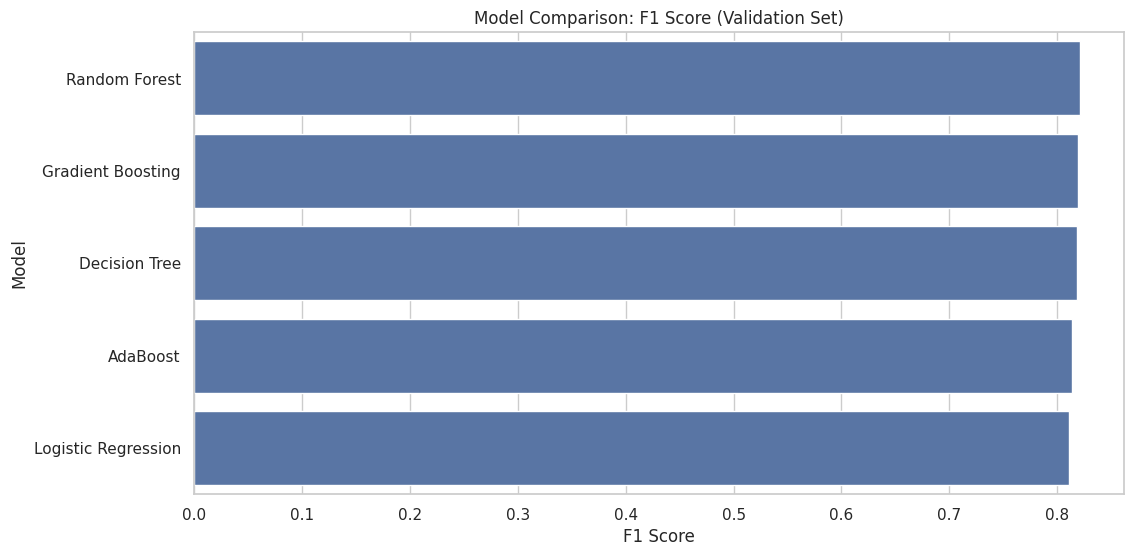


Best Model (Random Forest) on Test Set:
F1 Score: 0.8126
Accuracy: 0.7302
Precision: 0.7576
Recall: 0.8763
ROC-AUC: 0.7564


In [ ]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import seaborn as sns

# Load preprocessed datasets
train_df = pd.read_csv('train_processed.csv')
val_df = pd.read_csv('val_processed.csv')
test_df = pd.read_csv('test_processed.csv')

# Separate features and target
X_train = train_df.drop(columns=['case_status'])
y_train = train_df['case_status']
X_val = val_df.drop(columns=['case_status'])
y_val = val_df['case_status']
X_test = test_df.drop(columns=['case_status'])
y_test = test_df['case_status']

# Define models and parameters for tuning
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'AdaBoost': AdaBoostClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000)
}

param_grids = {
    'Decision Tree': {'max_depth': [5, 10], 'min_samples_split': [2, 10]},
    'Random Forest': {'n_estimators': [100, 200], 'max_depth': [10, 20]},
    'AdaBoost': {'n_estimators': [50, 100], 'learning_rate': [0.1, 1.0]},
    'Gradient Boosting': {'n_estimators': [100, 200], 'learning_rate': [0.1, 0.01]},
    'Logistic Regression': {'C': [0.1, 1.0]}
}

# Store results
results = {'Model': [], 'F1 Score (Val)': [], 'Accuracy (Val)': [], 'Precision (Val)': [], 'Recall (Val)': [], 'ROC-AUC (Val)': []}

# Train and evaluate each model
for name, model in models.items():
    print(f"\nTraining {name}...")
    # Perform grid search on validation set
    grid = GridSearchCV(model, param_grids[name], cv=3, scoring='f1', n_jobs=-1)
    grid.fit(X_train, y_train)

    # Best model
    best_model = grid.best_estimator_

    # Predict on validation set
    y_pred_val = best_model.predict(X_val)
    y_proba_val = best_model.predict_proba(X_val)[:, 1] if hasattr(best_model, 'predict_proba') else y_pred_val

    # Calculate metrics
    f1 = f1_score(y_val, y_pred_val)
    accuracy = accuracy_score(y_val, y_pred_val)
    precision = precision_score(y_val, y_pred_val)
    recall = recall_score(y_val, y_pred_val)
    roc_auc = roc_auc_score(y_val, y_proba_val) if hasattr(best_model, 'predict_proba') else np.nan

    # Store results
    results['Model'].append(name)
    results['F1 Score (Val)'].append(f1)
    results['Accuracy (Val)'].append(accuracy)
    results['Precision (Val)'].append(precision)
    results['Recall (Val)'].append(recall)
    results['ROC-AUC (Val)'].append(roc_auc)

    print(f"Best Params for {name}: {grid.best_params_}")
    print(f"F1 Score (Val): {f1:.4f}, Accuracy (Val): {accuracy:.4f}, Precision (Val): {precision:.4f}, Recall (Val): {recall:.4f}, ROC-AUC (Val): {roc_auc:.4f}")

# Convert results to DataFrame
results_df = pd.DataFrame(results)

# Visualize results
plt.figure(figsize=(12, 6))
sns.barplot(x='F1 Score (Val)', y='Model', data=results_df.sort_values('F1 Score (Val)', ascending=False))
plt.title('Model Comparison: F1 Score (Validation Set)')
plt.xlabel('F1 Score')
plt.show()

# Evaluate best model on test set
best_model_name = results_df.loc[results_df['F1 Score (Val)'].idxmax(), 'Model']
# Use the best_estimator_ from the grid search to evaluate on the test set
best_model = grid.best_estimator_
best_model.fit(X_train, y_train)
y_pred_test = best_model.predict(X_test)
y_proba_test = best_model.predict_proba(X_test)[:, 1] if hasattr(best_model, 'predict_proba') else y_pred_test

# Test set metrics
print(f"\nBest Model ({best_model_name}) on Test Set:")
print(f"F1 Score: {f1_score(y_test, y_pred_test):.4f}")
print(f"Accuracy: {accuracy_score(y_test, y_pred_test):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_test):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_test):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_test):.4f}")

Class distribution after SMOTE (Train):
case_status
1    0.5
0    0.5
Name: proportion, dtype: float64

Training Decision Tree...
Best Params for Decision Tree: {'max_depth': 10, 'min_samples_split': 2}
F1 Score (Val): 0.8020, Accuracy (Val): 0.7284, Precision (Val): 0.7817, Recall (Val): 0.8234, ROC-AUC (Val): 0.7511

Training Random Forest...
Best Params for Random Forest: {'max_depth': 10, 'n_estimators': 100}
F1 Score (Val): 0.8086, Accuracy (Val): 0.7372, Precision (Val): 0.7874, Recall (Val): 0.8311, ROC-AUC (Val): 0.7699

Training AdaBoost...
Best Params for AdaBoost: {'learning_rate': 1.0, 'n_estimators': 100}
F1 Score (Val): 0.7830, Accuracy (Val): 0.7035, Precision (Val): 0.7659, Recall (Val): 0.8008, ROC-AUC (Val): 0.7469

Training Gradient Boosting...
Best Params for Gradient Boosting: {'learning_rate': 0.1, 'n_estimators': 200}
F1 Score (Val): 0.8086, Accuracy (Val): 0.7347, Precision (Val): 0.7805, Recall (Val): 0.8387, ROC-AUC (Val): 0.7698

Training Logistic Regression.

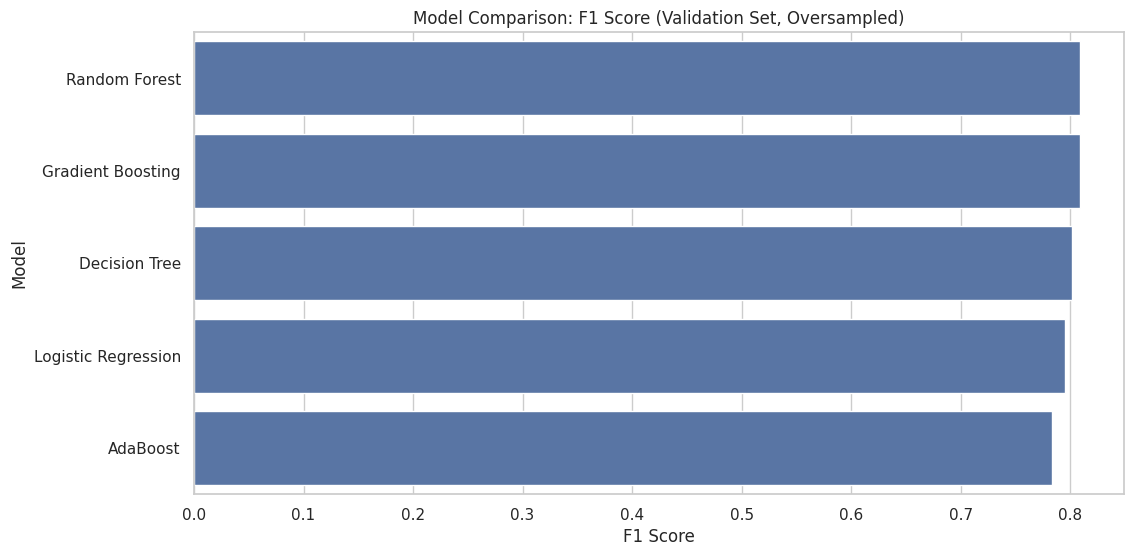


Best Model (Random Forest) on Test Set:
F1 Score: 0.7959
Accuracy: 0.7186
Precision: 0.7717
Recall: 0.8216
ROC-AUC: 0.7490


In [ ]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import GridSearchCV
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns

# Load preprocessed datasets
train_df = pd.read_csv('train_processed.csv')
val_df = pd.read_csv('val_processed.csv')
test_df = pd.read_csv('test_processed.csv')

# Separate features and target
X_train = train_df.drop(columns=['case_status'])
y_train = train_df['case_status']
X_val = val_df.drop(columns=['case_status'])
y_val = val_df['case_status']
X_test = test_df.drop(columns=['case_status'])
y_test = test_df['case_status']

# Apply SMOTE to training data
smote = SMOTE(random_state=42)
X_train_os, y_train_os = smote.fit_resample(X_train, y_train)

# Verify class balance after oversampling
print("Class distribution after SMOTE (Train):")
print(pd.Series(y_train_os).value_counts(normalize=True))

# Define models and parameters for tuning
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'AdaBoost': AdaBoostClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000)
}

param_grids = {
    'Decision Tree': {'max_depth': [5, 10], 'min_samples_split': [2, 10]},
    'Random Forest': {'n_estimators': [100, 200], 'max_depth': [10, 20]},
    'AdaBoost': {'n_estimators': [50, 100], 'learning_rate': [0.1, 1.0]},
    'Gradient Boosting': {'n_estimators': [100, 200], 'learning_rate': [0.1, 0.01]},
    'Logistic Regression': {'C': [0.1, 1.0]}
}

# Store results
results = {'Model': [], 'F1 Score (Val)': [], 'Accuracy (Val)': [], 'Precision (Val)': [], 'Recall (Val)': [], 'ROC-AUC (Val)': []}

# Train and evaluate each model
for name, model in models.items():
    print(f"\nTraining {name}...")
    # Perform grid search on oversampled training data
    grid = GridSearchCV(model, param_grids[name], cv=3, scoring='f1', n_jobs=-1)
    grid.fit(X_train_os, y_train_os)

    # Best model
    best_model = grid.best_estimator_

    # Predict on validation set
    y_pred_val = best_model.predict(X_val)
    y_proba_val = best_model.predict_proba(X_val)[:, 1] if hasattr(best_model, 'predict_proba') else y_pred_val

    # Calculate metrics
    f1 = f1_score(y_val, y_pred_val)
    accuracy = accuracy_score(y_val, y_pred_val)
    precision = precision_score(y_val, y_pred_val)
    recall = recall_score(y_val, y_pred_val)
    roc_auc = roc_auc_score(y_val, y_proba_val) if hasattr(best_model, 'predict_proba') else np.nan

    # Store results
    results['Model'].append(name)
    results['F1 Score (Val)'].append(f1)
    results['Accuracy (Val)'].append(accuracy)
    results['Precision (Val)'].append(precision)
    results['Recall (Val)'].append(recall)
    results['ROC-AUC (Val)'].append(roc_auc)

    print(f"Best Params for {name}: {grid.best_params_}")
    print(f"F1 Score (Val): {f1:.4f}, Accuracy (Val): {accuracy:.4f}, Precision (Val): {precision:.4f}, Recall (Val): {recall:.4f}, ROC-AUC (Val): {roc_auc:.4f}")

# Convert results to DataFrame
results_df = pd.DataFrame(results)

# Visualize results
plt.figure(figsize=(12, 6))
sns.barplot(x='F1 Score (Val)', y='Model', data=results_df.sort_values('F1 Score (Val)', ascending=False))
plt.title('Model Comparison: F1 Score (Validation Set, Oversampled)')
plt.xlabel('F1 Score')
plt.show()

# Evaluate best model on test set
best_model_name = results_df.loc[results_df['F1 Score (Val)'].idxmax(), 'Model']
# Use the best_estimator_ from the grid search to evaluate on the test set
best_model = grid.best_estimator_
best_model.fit(X_train_os, y_train_os)
y_pred_test = best_model.predict(X_test)
y_proba_test = best_model.predict_proba(X_test)[:, 1] if hasattr(best_model, 'predict_proba') else y_pred_test

# Test set metrics
print(f"\nBest Model ({best_model_name}) on Test Set:")
print(f"F1 Score: {f1_score(y_test, y_pred_test):.4f}")
print(f"Accuracy: {accuracy_score(y_test, y_pred_test):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_test):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_test):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_test):.4f}")

Class distribution after RandomUnderSampler (Train):
case_status
0    0.5
1    0.5
Name: proportion, dtype: float64
Training set size after undersampling: (10154, 21)

Training Decision Tree...
Best Params for Decision Tree: {'max_depth': 5, 'min_samples_split': 2}
F1 Score (Val): 0.7856, Accuracy (Val): 0.7186, Precision (Val): 0.7999, Recall (Val): 0.7717, ROC-AUC (Val): 0.7558

Training Random Forest...
Best Params for Random Forest: {'max_depth': 10, 'n_estimators': 200}
F1 Score (Val): 0.7707, Accuracy (Val): 0.7102, Precision (Val): 0.8173, Recall (Val): 0.7291, ROC-AUC (Val): 0.7752

Training AdaBoost...
Best Params for AdaBoost: {'learning_rate': 0.1, 'n_estimators': 100}
F1 Score (Val): 0.7830, Accuracy (Val): 0.7117, Precision (Val): 0.7875, Recall (Val): 0.7785, ROC-AUC (Val): 0.7483

Training Gradient Boosting...
Best Params for Gradient Boosting: {'learning_rate': 0.01, 'n_estimators': 200}
F1 Score (Val): 0.7830, Accuracy (Val): 0.7166, Precision (Val): 0.8015, Recall (Va

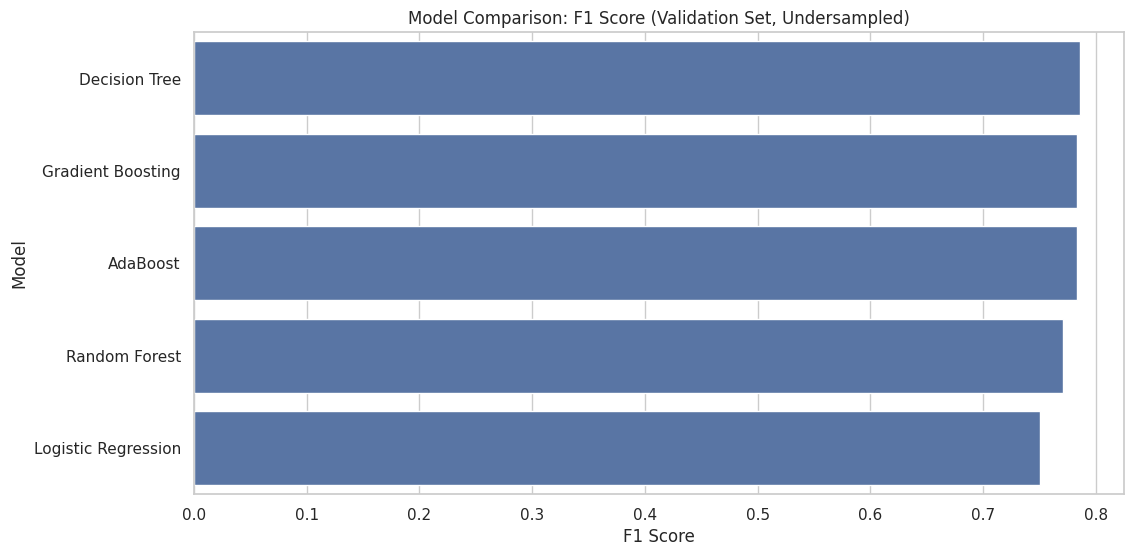


Best Model (Decision Tree) on Test Set:
F1 Score: 0.7447
Accuracy: 0.6862
Precision: 0.8154
Recall: 0.6853
ROC-AUC: 0.7554


In [ ]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import GridSearchCV
from imblearn.under_sampling import RandomUnderSampler
import matplotlib.pyplot as plt
import seaborn as sns

# Load preprocessed datasets
train_df = pd.read_csv('train_processed.csv')
val_df = pd.read_csv('val_processed.csv')
test_df = pd.read_csv('test_processed.csv')

# Separate features and target
X_train = train_df.drop(columns=['case_status'])
y_train = train_df['case_status']
X_val = val_df.drop(columns=['case_status'])
y_val = val_df['case_status']
X_test = test_df.drop(columns=['case_status'])
y_test = test_df['case_status']

# Apply RandomUnderSampler to training data
rus = RandomUnderSampler(random_state=42)
X_train_us, y_train_us = rus.fit_resample(X_train, y_train)

# Verify class balance after undersampling
print("Class distribution after RandomUnderSampler (Train):")
print(pd.Series(y_train_us).value_counts(normalize=True))
print("Training set size after undersampling:", X_train_us.shape)

# Define models and parameters for tuning
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'AdaBoost': AdaBoostClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000)
}

param_grids = {
    'Decision Tree': {'max_depth': [5, 10], 'min_samples_split': [2, 10]},
    'Random Forest': {'n_estimators': [100, 200], 'max_depth': [10, 20]},
    'AdaBoost': {'n_estimators': [50, 100], 'learning_rate': [0.1, 1.0]},
    'Gradient Boosting': {'n_estimators': [100, 200], 'learning_rate': [0.1, 0.01]},
    'Logistic Regression': {'C': [0.1, 1.0]}
}

# Store results
results = {'Model': [], 'F1 Score (Val)': [], 'Accuracy (Val)': [], 'Precision (Val)': [], 'Recall (Val)': [], 'ROC-AUC (Val)': []}

# Train and evaluate each model
for name, model in models.items():
    print(f"\nTraining {name}...")
    # Perform grid search on undersampled training data
    grid = GridSearchCV(model, param_grids[name], cv=3, scoring='f1', n_jobs=-1)
    grid.fit(X_train_us, y_train_us)

    # Best model
    best_model = grid.best_estimator_

    # Predict on validation set
    y_pred_val = best_model.predict(X_val)
    y_proba_val = best_model.predict_proba(X_val)[:, 1] if hasattr(best_model, 'predict_proba') else y_pred_val

    # Calculate metrics
    f1 = f1_score(y_val, y_pred_val)
    accuracy = accuracy_score(y_val, y_pred_val)
    precision = precision_score(y_val, y_pred_val)
    recall = recall_score(y_val, y_pred_val)
    roc_auc = roc_auc_score(y_val, y_proba_val) if hasattr(best_model, 'predict_proba') else np.nan

    # Store results
    results['Model'].append(name)
    results['F1 Score (Val)'].append(f1)
    results['Accuracy (Val)'].append(accuracy)
    results['Precision (Val)'].append(precision)
    results['Recall (Val)'].append(recall)
    results['ROC-AUC (Val)'].append(roc_auc)

    print(f"Best Params for {name}: {grid.best_params_}")
    print(f"F1 Score (Val): {f1:.4f}, Accuracy (Val): {accuracy:.4f}, Precision (Val): {precision:.4f}, Recall (Val): {recall:.4f}, ROC-AUC (Val): {roc_auc:.4f}")

# Convert results to DataFrame
results_df = pd.DataFrame(results)

# Visualize results
plt.figure(figsize=(12, 6))
sns.barplot(x='F1 Score (Val)', y='Model', data=results_df.sort_values('F1 Score (Val)', ascending=False))
plt.title('Model Comparison: F1 Score (Validation Set, Undersampled)')
plt.xlabel('F1 Score')
plt.show()

# Evaluate best model on test set
best_model_name = results_df.loc[results_df['F1 Score (Val)'].idxmax(), 'Model']
# Use the best_estimator_ from the grid search to evaluate on the test set
best_model = grid.best_estimator_
best_model.fit(X_train_us, y_train_us)
y_pred_test = best_model.predict(X_test)
y_proba_test = best_model.predict_proba(X_test)[:, 1] if hasattr(best_model, 'predict_proba') else y_pred_test

# Test set metrics
print(f"\nBest Model ({best_model_name}) on Test Set:")
print(f"F1 Score: {f1_score(y_test, y_pred_test):.4f}")
print(f"Accuracy: {accuracy_score(y_test, y_pred_test):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_test):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_test):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_test):.4f}")

Class distribution after SMOTE (Train):
case_status
1    0.5
0    0.5
Name: proportion, dtype: float64

Tuning Random Forest...
Best Params for Random Forest: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 10}
F1 Score (Val): 0.8077, Accuracy (Val): 0.7361, Precision (Val): 0.7867, Recall (Val): 0.8299, ROC-AUC (Val): 0.7710

Tuning Gradient Boosting...
Best Params for Gradient Boosting: {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 7, 'learning_rate': 0.05}
F1 Score (Val): 0.8134, Accuracy (Val): 0.7408, Precision (Val): 0.7834, Recall (Val): 0.8458, ROC-AUC (Val): 0.7756

Tuning AdaBoost...
Best Params for AdaBoost: {'n_estimators': 200, 'learning_rate': 0.5}
F1 Score (Val): 0.7894, Accuracy (Val): 0.7109, Precision (Val): 0.7690, Recall (Val): 0.8108, ROC-AUC (Val): 0.7510


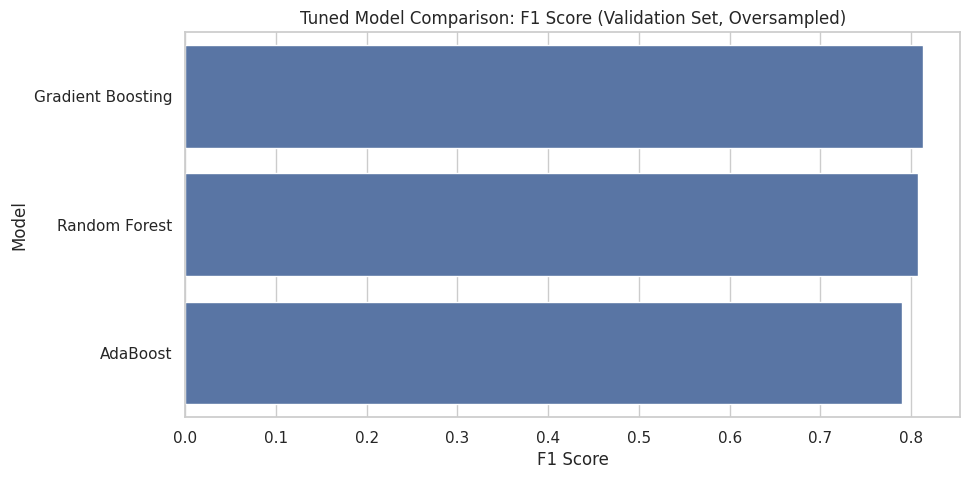


Best Model (Gradient Boosting) on Test Set:
F1 Score: 0.8034
Accuracy: 0.7284
Precision: 0.7777
Recall: 0.8307
ROC-AUC: 0.7541


In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import RandomizedSearchCV
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns

# Load preprocessed datasets
train_df = pd.read_csv('train_processed.csv')
val_df = pd.read_csv('val_processed.csv')
test_df = pd.read_csv('test_processed.csv')

# Separate features and target
X_train = train_df.drop(columns=['case_status'])
y_train = train_df['case_status']
X_val = val_df.drop(columns=['case_status'])
y_val = val_df['case_status']
X_test = test_df.drop(columns=['case_status'])
y_test = test_df['case_status']

# Apply SMOTE to training data (recreate oversampled data)
smote = SMOTE(random_state=42)
X_train_os, y_train_os = smote.fit_resample(X_train, y_train)

# Verify class balance
print("Class distribution after SMOTE (Train):")
print(pd.Series(y_train_os).value_counts(normalize=True))

# Define models and parameter distributions for Randomized Search
models = {
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'AdaBoost': AdaBoostClassifier(random_state=42)
}

param_distributions = {
    'Random Forest': {
        'n_estimators': [100, 200, 300, 400],
        'max_depth': [10, 20, 30, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2']
    },
    'Gradient Boosting': {
        'n_estimators': [100, 200, 300],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'max_depth': [3, 5, 7],
        'subsample': [0.8, 0.9, 1.0]
    },
    'AdaBoost': {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.1, 0.5, 1.0]
    }
}

# Store results
results = {'Model': [], 'F1 Score (Val)': [], 'Accuracy (Val)': [], 'Precision (Val)': [], 'Recall (Val)': [], 'ROC-AUC (Val)': []}

# Tune and evaluate each model
for name, model in models.items():
    print(f"\nTuning {name}...")
    # Perform Randomized Search
    random_search = RandomizedSearchCV(
        model,
        param_distributions[name],
        n_iter=10,
        cv=3,
        scoring='f1',
        n_jobs=-1,
        random_state=42
    )
    random_search.fit(X_train_os, y_train_os)

    # Best model
    best_model = random_search.best_estimator_

    # Predict on validation set
    y_pred_val = best_model.predict(X_val)
    y_proba_val = best_model.predict_proba(X_val)[:, 1] if hasattr(best_model, 'predict_proba') else y_pred_val

    # Calculate metrics
    f1 = f1_score(y_val, y_pred_val)
    accuracy = accuracy_score(y_val, y_pred_val)
    precision = precision_score(y_val, y_pred_val)
    recall = recall_score(y_val, y_pred_val)
    roc_auc = roc_auc_score(y_val, y_proba_val) if hasattr(best_model, 'predict_proba') else np.nan

    # Store results
    results['Model'].append(name)
    results['F1 Score (Val)'].append(f1)
    results['Accuracy (Val)'].append(accuracy)
    results['Precision (Val)'].append(precision)
    results['Recall (Val)'].append(recall)
    results['ROC-AUC (Val)'].append(roc_auc)

    print(f"Best Params for {name}: {random_search.best_params_}")
    print(f"F1 Score (Val): {f1:.4f}, Accuracy (Val): {accuracy:.4f}, Precision (Val): {precision:.4f}, Recall (Val): {recall:.4f}, ROC-AUC (Val): {roc_auc:.4f}")

# Convert results to DataFrame
results_df = pd.DataFrame(results)

# Visualize results
plt.figure(figsize=(10, 5))
sns.barplot(x='F1 Score (Val)', y='Model', data=results_df.sort_values('F1 Score (Val)', ascending=False))
plt.title('Tuned Model Comparison: F1 Score (Validation Set, Oversampled)')
plt.xlabel('F1 Score')
plt.show()

# Evaluate best model on test set
best_model_name = results_df.loc[results_df['F1 Score (Val)'].idxmax(), 'Model']
best_model = models[best_model_name].set_params(**random_search.best_params_)
best_model.fit(X_train_os, y_train_os)
y_pred_test = best_model.predict(X_test)
y_proba_test = best_model.predict_proba(X_test)[:, 1] if hasattr(best_model, 'predict_proba') else y_pred_test

# Test set metrics
print(f"\nBest Model ({best_model_name}) on Test Set:")
print(f"F1 Score: {f1_score(y_test, y_pred_test):.4f}")
print(f"Accuracy: {accuracy_score(y_test, y_pred_test):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_test):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_test):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_test):.4f}")